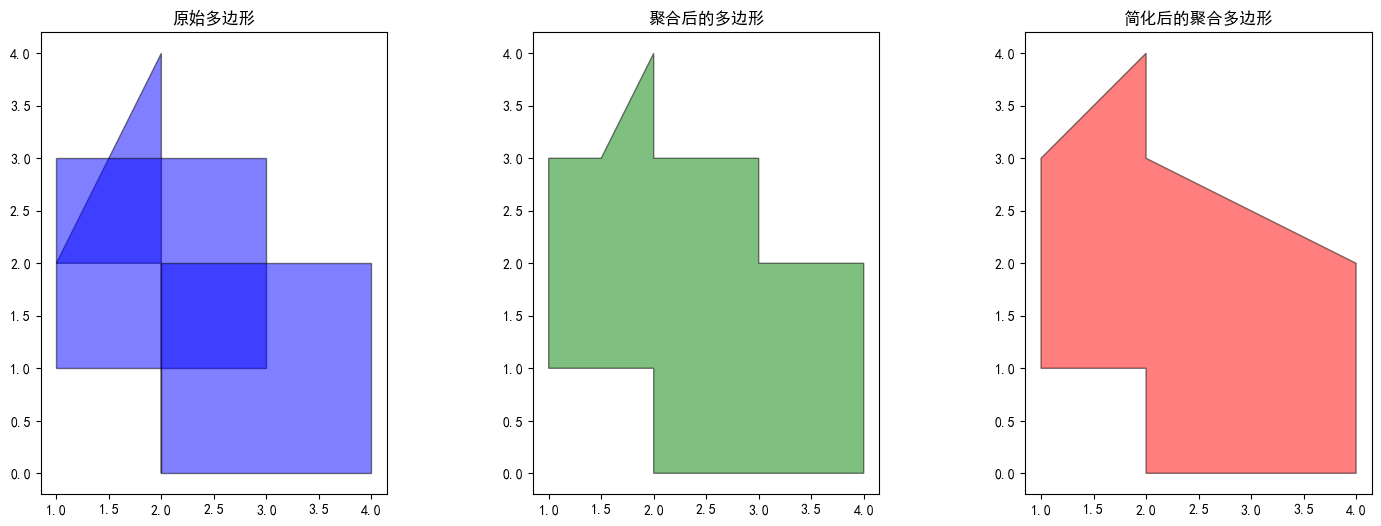

In [6]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union

plt.rcParams['font.family'] = ['SimHei']  # 这里使用黑体，你也可以换成其他支持中文的字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题

def plot_polygons(geometry, title, ax, color='blue', alpha=0.5):
    """
    绘制各种类型的几何对象，包括 Polygon、MultiPolygon 和 GeometryCollection。
    """
    if geometry.is_empty:
        return

    if isinstance(geometry, Polygon):
        x, y = geometry.exterior.xy
        ax.fill(x, y, alpha=alpha, fc=color, ec='black')
    elif isinstance(geometry, MultiPolygon):
        for poly in geometry:
            x, y = poly.exterior.xy
            ax.fill(x, y, alpha=alpha, fc=color, ec='black')
    elif geometry.geom_type == 'GeometryCollection':
        for geom in geometry:
            plot_polygons(geom, title, ax, color, alpha)
    else:
        print(f"Unsupported geometry type: {geometry.geom_type}")

    ax.set_title(title)
    ax.set_aspect('equal')

def aggregate_approximation():
    # 定义多个重叠的多边形
    poly1 = Polygon([(2, 2), (2, 0), (2, 4), (1, 2)])
    poly2 = Polygon([(1, 1), (3, 1), (3, 3), (1, 3)])
    poly3 = Polygon([(2, 0), (4, 0), (4, 2), (2, 2)])

    polygons = [poly1, poly2, poly3]

    # 创建图形和坐标轴
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # 原始多边形
#     plot_polygons(unary_union(polygons), '原始多边形', axs[0], color='blue')
    
    for poly in polygons:
        plot_polygons(poly, '原始多边形', axs[0], color='blue', alpha=0.5)

    # 聚合（联合）多边形
    aggregated = unary_union(polygons)
    plot_polygons(aggregated, '聚合后的多边形', axs[1], color='green')

    # 简化聚合后的多边形（可选）
    simplified = aggregated.simplify(tolerance=0.5, preserve_topology=True)
    plot_polygons(simplified, '简化后的聚合多边形', axs[2], color='red')

    plt.show()

if __name__ == "__main__":
    aggregate_approximation()


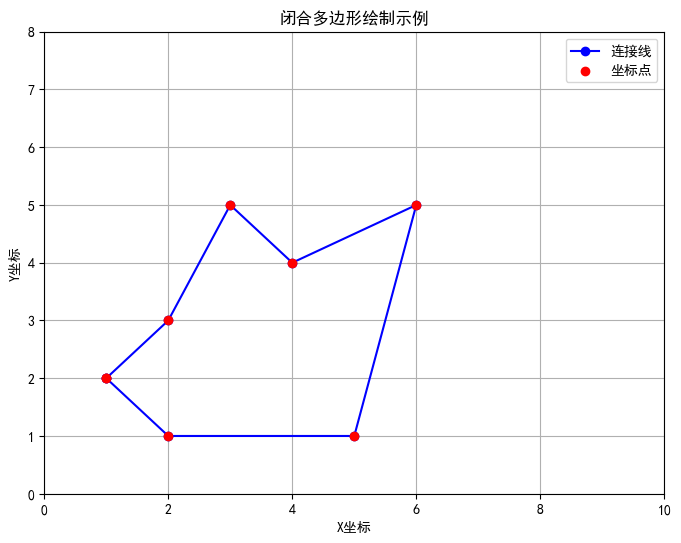

In [32]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

# 示例坐标点（闭合多边形）
points = [
    (1, 2),
    (2, 3),
    (3, 5),
    (4, 4),
    (6, 5),
    (5, 1),
    (2,1 ),
    (1, 2)  # 重复第一个点以闭合多边形
]

# 分离x和y坐标
x, y = zip(*points)
# y = [i-1 for i in y]

# 创建一个新的图形
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制多边形填充
# polygon = MplPolygon(points, closed=True, fill=True, edgecolor='black', facecolor='lightblue', alpha=0.5, label='多边形填充')
# ax.add_patch(polygon)

# 绘制连接线
plt.plot(x, y, linestyle='-', marker='o', color='blue', label='连接线')

# 绘制单独的点
plt.scatter(x, y, color='red', zorder=5, label='坐标点')

# 设置轴范围
plt.xlim(0, 10)
plt.ylim(0, 8)

# 添加标题和标签
plt.title('闭合多边形绘制示例')
plt.xlabel('X坐标')
plt.ylabel('Y坐标')

# 显示图例
plt.legend()

# 添加网格
plt.grid(True)

# 显示图形
plt.show()


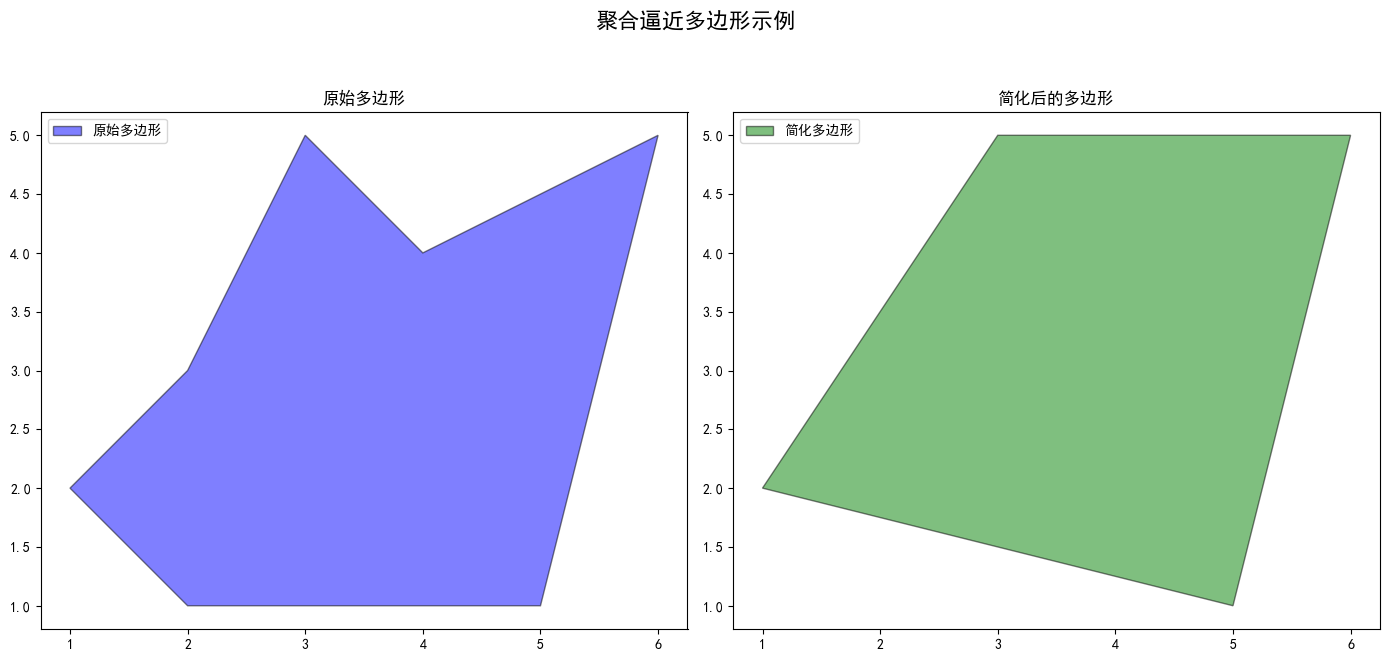

In [38]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.ops import unary_union

# 设置中文显示和负号显示（如果需要）
plt.rcParams['font.family'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题

def plot_polygon(ax, polygon, title, color='blue', alpha=0.5, label='多边形'):
    """
    绘制单个多边形。
    """
    if polygon.is_empty:
        print("多边形为空，无法绘制。")
        return

    # 检查多边形是否有效
    if not polygon.is_valid:
        print("多边形无效，尝试修复。")
        polygon = polygon.buffer(0)

    # 绘制多边形
    x, y = polygon.exterior.xy
    ax.fill(x, y, alpha=alpha, fc=color, ec='black', label=label)

    # 设置标题和比例
    ax.set_title(title)
    ax.set_aspect('equal')

def aggregate_approximation():
    # 定义一系列坐标点，形成一个闭合多边形
    points = [
        (1, 2),
        (2, 3),
        (3, 5),
        (4, 4),
        (6, 5),
        (5, 1),
        (2,1 ),
        (1, 2)  # 重复第一个点以闭合多边形
    ]

    # 创建Shapely的多边形对象
    original_polygon = Polygon(points)

    # 检查多边形的有效性
    if not original_polygon.is_valid:
        print("原始多边形无效，尝试修复。")
        original_polygon = original_polygon.buffer(0)
        if not original_polygon.is_valid:
            print("修复后的多边形仍然无效，请检查坐标点。")
            return

    # 聚合逼近（简化）多边形
    # tolerance参数控制简化程度，值越大，简化程度越高
    tolerance = 1.0
    simplified_polygon = original_polygon.simplify(tolerance, preserve_topology=True)


    # 创建图形和坐标轴
    fig, axs = plt.subplots(1, 2, figsize=(14, 7))

    # 绘制原始多边形
    plot_polygon(axs[0], original_polygon, '原始多边形', color='blue', alpha=0.5, label='原始多边形')
    axs[0].legend()

    # 绘制简化后的多边形
    plot_polygon(axs[1], simplified_polygon, '简化后的多边形', color='green', alpha=0.5, label='简化多边形')
    axs[1].legend()

    # 设置整体标题
    fig.suptitle('聚合逼近多边形示例', fontsize=16)

    # 显示图形
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    aggregate_approximation()


In [36]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, MultiPolygon, GeometryCollection
from shapely.ops import split

# 设置中文显示和负号显示（如果需要）
plt.rcParams['font.family'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题

def plot_polygons(geometries, title, ax, colors=None, alpha=0.5):
    """
    绘制各种类型的几何对象，包括 Polygon、MultiPolygon 和 GeometryCollection。
    
    参数:
        geometries: Shapely 的几何对象
        title: 子图标题
        ax: Matplotlib 的轴对象
        colors: 多边形填充颜色列表或单一颜色
        alpha: 填充透明度
    """
    if geometries.is_empty:
        print("几何对象为空，无法绘制。")
        return

    # 处理不同类型的几何对象
    if isinstance(geometries, Polygon):
        geometries = [geometries]
    elif isinstance(geometries, MultiPolygon):
        geometries = list(geometries)
    elif geometries.geom_type == 'GeometryCollection':
        # 过滤出 Polygon 类型
        geometries = [geom for geom in geometries if isinstance(geom, Polygon)]
    else:
        print(f"不支持的几何类型: {geometries.geom_type}")
        geometries = []

    # 处理颜色
    if colors is None:
        colors = ['blue'] * len(geometries)
    elif isinstance(colors, str):
        colors = [colors] * len(geometries)
    elif len(colors) < len(geometries):
        # 重复颜色以匹配多边形数量
        colors = colors * (len(geometries) // len(colors) + 1)

    # 绘制每个多边形
    for geom, color in zip(geometries, colors):
        if isinstance(geom, Polygon):
            x, y = geom.exterior.xy
            ax.fill(x, y, alpha=alpha, fc=color, ec='black')
        else:
            print(f"Unsupported geometry type during plotting: {geom.geom_type}")

    # 设置标题和比例
    ax.set_title(title)
    ax.set_aspect('equal')

def split_approximation():
    # 定义一系列坐标点，形成一个闭合多边形
    points = [
        (1, 2),
        (2, 3),
        (3, 5),
        (4, 4),
        (6, 5),
        (5, 1),
        (2, 1),
        (1, 2)  # 重复第一个点以闭合多边形
    ]

    # 创建Shapely的多边形对象
    original_polygon = Polygon(points)

    # 检查多边形的有效性
    if not original_polygon.is_valid:
        print("原始多边形无效，尝试修复。")
        original_polygon = original_polygon.buffer(0)
        if not original_polygon.is_valid:
            print("修复后的多边形仍然无效，请检查坐标点。")
            return

    # 定义切割线
    # 这里选择一条水平线 y=3.0 作为切割线，你可以根据需要调整
    cutter = LineString([(1, 3.0), (6, 3.0)])

    # 检查切割线是否与多边形相交
    if not original_polygon.intersects(cutter):
        print("切割线与多边形不相交，无法进行分割。")
        return

    # 分裂多边形
    split_result = split(original_polygon, cutter)

    # 检查分裂结果的类型
    if isinstance(split_result, (MultiPolygon, GeometryCollection)):
        splitted_polygons = [geom for geom in split_result if isinstance(geom, Polygon)]
    elif isinstance(split_result, Polygon):
        splitted_polygons = [split_result]
    else:
        print(f"Unexpected geometry type after split: {split_result.geom_type}")
        return

    # 创建图形和坐标轴
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # 绘制原始多边形
    plot_polygons(original_polygon, '原始多边形', axs[0], color='blue', alpha=0.5)
    
    # 绘制切割线
    x_cutter, y_cutter = cutter.xy
    axs[0].plot(x_cutter, y_cutter, color='red', linestyle='--', linewidth=2, label='切割线')
    axs[0].legend()

    # 绘制分裂后的多边形
    if splitted_polygons:
        plot_polygons(MultiPolygon(splitted_polygons), '分裂后的多边形', axs[1], colors=['green', 'orange'], alpha=0.5)
    else:
        print("没有生成分裂后的多边形。")

    # 简化分裂后的多边形（可选）
    simplified_polygons = []
    tolerance = 0.5  # 调整简化程度
    for poly in splitted_polygons:
        simplified = poly.split(tolerance, preserve_topology=True)
#         simplified = poly.simplify(tolerance, preserve_topology=True)
        
        if simplified.is_valid:
            simplified_polygons.append(simplified)
        else:
            # 尝试修复简化后的多边形
            simplified = simplified.buffer(0)
            if simplified.is_valid:
                simplified_polygons.append(simplified)
            else:
                print("简化后的多边形无效，跳过。")

    if simplified_polygons:
        plot_polygons(MultiPolygon(simplified_polygons), '简化后的分裂多边形', axs[2], colors=['purple', 'yellow'], alpha=0.5)
    else:
        print("没有生成简化后的分裂多边形。")

    # 设置整体标题
    fig.suptitle('分裂逼近多边形示例', fontsize=16)

    # 调整布局
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # 显示图形
    plt.show()

if __name__ == "__main__":
    split_approximation()


TypeError: 'GeometryCollection' object is not iterable